Found 60000 files.
Found 10000 files.
Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


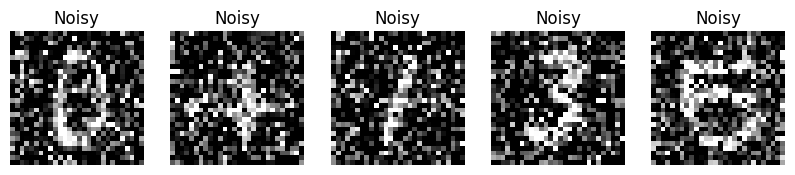

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - loss: 0.1771 - val_loss: 0.1222
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - loss: 0.1176 - val_loss: 0.1127
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1117 - val_loss: 0.1088
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.1086 - val_loss: 0.1065
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.1066 - val_loss: 0.1050
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.1050 - val_loss: 0.1033
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - loss: 0.1037 - val_loss: 0.1024
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.1026 - val_loss: 0.1012
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.1018 - val_loss: 0.1009
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.1012 - val_loss: 0.1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


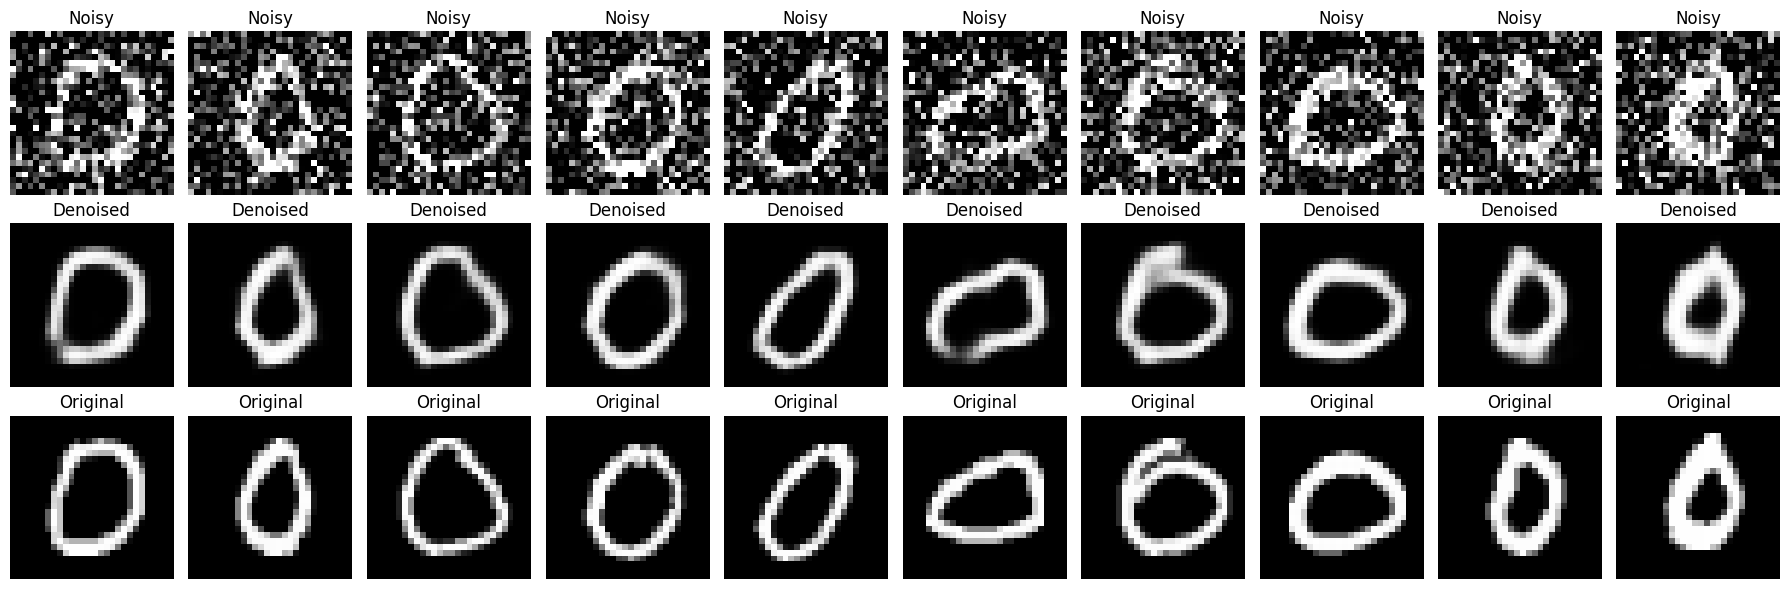

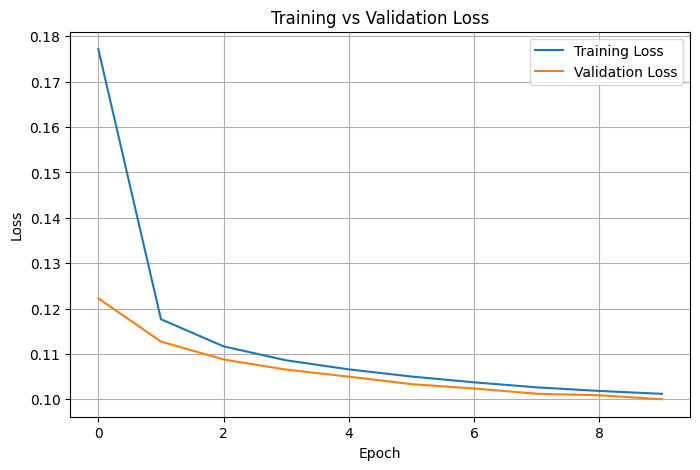

In [7]:
# ==========================================================
# Image Denoising using Autoencoder on MNIST (Kaggle Optimized)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# --------------------------------------------------
# Dataset Paths
# --------------------------------------------------
train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
test_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

# --------------------------------------------------
# Load Dataset
# --------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels=None,
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=128,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels=None,
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=128,
    shuffle=False
)

# --------------------------------------------------
# Convert Dataset to NumPy
# --------------------------------------------------
x_train = np.concatenate([x.numpy() for x in train_ds], axis=0)
x_test = np.concatenate([x.numpy() for x in test_ds], axis=0)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

# --------------------------------------------------
# Add Gaussian Noise
# --------------------------------------------------
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# --------------------------------------------------
# Show Sample Noisy Images
# --------------------------------------------------
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

plt.show()

# --------------------------------------------------
# Build Autoencoder
# --------------------------------------------------
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2,2), padding="same")(x)

x = Conv2D(16, (3,3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2,2), padding="same")(x)

# Decoder
x = Conv2D(16, (3,3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded)

# --------------------------------------------------
# Compile
# --------------------------------------------------
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

# --------------------------------------------------
# Train
# --------------------------------------------------
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    shuffle=True,
    verbose=1
)

# --------------------------------------------------
# Predict
# --------------------------------------------------
decoded_imgs = autoencoder.predict(x_test_noisy)

# --------------------------------------------------
# Show Results
# --------------------------------------------------
n = 10

plt.figure(figsize=(18,6))

for i in range(n):

    # Noisy
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # Original
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Loss Graph
# --------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()













In [2]:
import os

print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets"))
print(os.listdir("/kaggle/input/datasets/awsaf49"))
print(os.listdir("/kaggle/input/datasets/awsaf49/mnist-dataset"))

['datasets']
['awsaf49']
['mnist-dataset']
['mnist_png']


In [3]:
import os

print(os.listdir("/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png"))

['training', 'testing']


In [4]:
print(os.listdir("/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training")[:10])

['7', '2', '5', '8', '0', '3', '1', '4', '9', '6']


In [5]:
import tensorflow as tf

train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels=None,
    color_mode="grayscale",
    image_size=(28,28),
    batch_size=32
)

print("Dataset loaded successfully!")

Found 60000 files.
Dataset loaded successfully!
